In [1]:
#### This cell works- queries for directory (example below) and shows all sky images
# Ensure matplotlib plots are displayed inline in the notebook
%matplotlib inline

# directory is here:
# /sdf/data/rubin/offline/s3-backup/lfa/AllSkyCamera/2024/07/26

import os
import io
from PIL import Image
import rawpy
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
from ipywidgets import Output

output = Output()

# Function to list files in the directory
def list_files(directory, extension=".cr2"):
    files = [f for f in os.listdir(directory) if f.lower().endswith(extension)]
    with output:
        print(f"Listing files in directory: {directory}")
        print(f"Found files: {files}")
    return files

# Function to open and process a CR2 file
def open_file(filepath):
    with output:
        print(f"Opening file: {filepath}")
    try:
        with rawpy.imread(filepath) as raw:
            rgb = raw.postprocess()
        with output:
            print("File opened and processed successfully")
        return Image.fromarray(rgb)
    except Exception as e:
        with output:
            print(f"Error opening file: {e}")
        return None

# Function to display the image in the notebook using matplotlib
def display_image(image):
    if image:
        with output:
            print("Displaying image")
            plt.figure(figsize=(10, 10))
            plt.imshow(image)
            plt.axis('off')  # Hide axes
            plt.show()
    else:
        with output:
            print("No image to display")

# Directory input widget
directory_input = widgets.Text(
    value='',
    placeholder='Enter directory path',
    description='Directory:',
    disabled=False
)

# Dropdown for file selection
file_dropdown = widgets.Dropdown(
    options=[],
    description='File:',
    disabled=False
)

# Function to update the file dropdown based on the directory
def update_files(change):
    with output:
        print("Update files triggered")
    clear_output(wait=True)
    display(directory_input, file_dropdown, display_button, output)
    directory = directory_input.value
    if os.path.isdir(directory):
        with output:
            print(f"Valid directory: {directory}")
        files = list_files(directory)
        file_dropdown.options = files
    else:
        with output:
            print("Invalid directory")
        file_dropdown.options = []

directory_input.observe(update_files, names='value')

# Button to display the selected image
display_button = widgets.Button(
    description='Display Image',
    disabled=False,
    button_style='', 
    tooltip='Click to display the selected image',
    icon='image'
)

# Function to display the selected image when the button is clicked
def on_display_button_clicked(b):
    with output:
        print("Display button clicked")
    clear_output(wait=True)
    display(directory_input, file_dropdown, display_button, output)
    directory = directory_input.value
    filename = file_dropdown.value
    with output:
        print(f"Selected directory: {directory}")
        print(f"Selected file: {filename}")
    if filename:
        filepath = os.path.join(directory, filename)
        with output:
            print(f"Selected file path: {filepath}")  # Diagnostic print
        try:
            image = open_file(filepath)
            display_image(image)
            with output:
                print("Image displayed successfully")  # Diagnostic print
        except Exception as e:
            with output:
                print(f"Error displaying image: {e}")  # Diagnostic print
    else:
        with output:
            print("No file selected")

display_button.on_click(on_display_button_clicked)

# Display the widgets
with output:
    print("Displaying widgets")
display(directory_input, file_dropdown, display_button, output)


Text(value='', description='Directory:', placeholder='Enter directory path')

Dropdown(description='File:', options=(), value=None)

Button(description='Display Image', icon='image', style=ButtonStyle(), tooltip='Click to display the selected …

Output()

In [2]:
# Ensure matplotlib plots are displayed inline in the notebook
%matplotlib inline

import os
import time
from PIL import Image
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
from ipywidgets import Output

output = Output()

# Function to list files in the directory
def list_files(directory, extension=".jpg"):
    files = sorted([f for f in os.listdir(directory) if f.lower().endswith(extension)])
    return files

# Function to filter files based on sequence numbers
def filter_files(files, start_seq, stop_seq):
    filtered_files = []
    for file in files:
        try:
            seq_num = int(file[6:10])
            if start_seq <= seq_num <= stop_seq:
                filtered_files.append(file)
        except ValueError:
            pass
    return filtered_files

# Function to open and process a JPG file
def open_file(filepath):
    try:
        image = Image.open(filepath)
        return image
    except Exception as e:
        with output:
            print(f"Error opening file: {e}")
        return None

# Function to display the image in the notebook using matplotlib
def display_image(image):
    if image:
        plt.figure(figsize=(10, 10))
        plt.imshow(image)
        plt.axis('off')  # Hide axes
        plt.show()

# Directory input widget
directory_input = widgets.Text(
    value='/sdf/data/rubin/offline/s3-backup/lfa/AllSkyCamera/2025/01/22',  # Default directory path
    placeholder='Enter directory path',
    description='Directory:',
    disabled=False
)

# Slider for setting the delay
delay_slider = widgets.FloatSlider(
    value=1.0,
    min=0.1,
    max=10.0,
    step=0.1,
    description='Delay (s):',
    disabled=False
)

# Widgets for setting start and stop sequence numbers
start_seq_input = widgets.IntText(
    value=1,
    description='Start Seq:',
    disabled=False
)

stop_seq_input = widgets.IntText(
    value=100,
    description='Stop Seq:',
    disabled=False
)

# Playback control buttons
play_button = widgets.Button(description="Play", icon="play")
pause_button = widgets.Button(description="Pause", icon="pause")
forward_button = widgets.Button(description="Forward", icon="forward")
backward_button = widgets.Button(description="Backward", icon="backward")

# Function to update the file list based on the directory
def update_files(change):
    clear_output(wait=True)
    display_controls()
    directory = directory_input.value
    if os.path.isdir(directory):
        global files
        files = list_files(directory)
        global file_index
        file_index = 0

directory_input.observe(update_files, names='value')

# Function to display the image at the current index
def display_current_image():
    global file_index
    if 0 <= file_index < len(files):
        filepath = os.path.join(directory_input.value, files[file_index])
        image = open_file(filepath)
        display_image(image)

# Play slideshow function
def play_slideshow():
    global playing
    playing = True
    start_seq = start_seq_input.value
    stop_seq = stop_seq_input.value
    global files
    files = filter_files(files, start_seq, stop_seq)
    while playing and file_index < len(files):
        display_current_image()
        time.sleep(delay_slider.value)
        clear_output(wait=True)
        display_controls()
        next_image()

# Pause slideshow function
def pause_slideshow(b):
    global playing
    playing = False

# Next image function
def next_image():
    global file_index
    if file_index < len(files) - 1:
        file_index += 1

# Previous image function
def previous_image():
    global file_index
    if file_index > 0:
        file_index -= 1

# Play button click event
def on_play_button_clicked(b):
    global playing
    if not playing:
        playing = True
        play_slideshow()

# Forward button click event
def on_forward_button_clicked(b):
    global playing
    playing = False
    next_image()
    display_current_image()

# Backward button click event
def on_backward_button_clicked(b):
    global playing
    playing = False
    previous_image()
    display_current_image()

# Connect button click events to functions
play_button.on_click(on_play_button_clicked)
pause_button.on_click(pause_slideshow)
forward_button.on_click(on_forward_button_clicked)
backward_button.on_click(on_backward_button_clicked)

# Function to display all controls
def display_controls():
    display(directory_input, start_seq_input, stop_seq_input, delay_slider, play_button, pause_button, forward_button, backward_button, output)

# Display the widgets
display_controls()


Text(value='/sdf/data/rubin/offline/s3-backup/lfa/AllSkyCamera/2025/01/22', description='Directory:', placehol…

IntText(value=1, description='Start Seq:')

IntText(value=100, description='Stop Seq:')

FloatSlider(value=1.0, description='Delay (s):', max=10.0, min=0.1)

Button(description='Play', icon='play', style=ButtonStyle())

Button(description='Pause', icon='pause', style=ButtonStyle())

Button(description='Forward', icon='forward', style=ButtonStyle())

Button(description='Backward', icon='backward', style=ButtonStyle())

Output()

Loading first image: /sdf/data/rubin/offline/s3-backup/lfa/AllSkyCamera/2025/01/22/asc2501220001.jpg


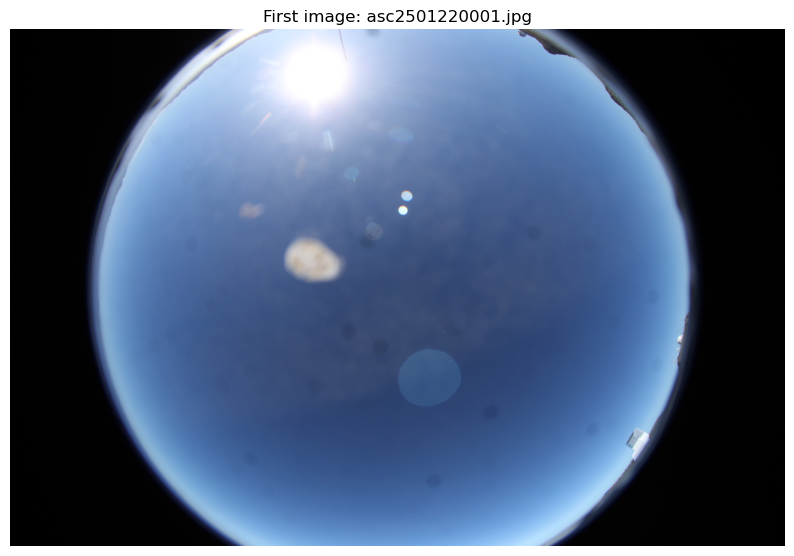

In [3]:
import os
import matplotlib.pyplot as plt
from PIL import Image

# Directory containing your images
image_directory = "/sdf/data/rubin/offline/s3-backup/lfa/AllSkyCamera/2025/01/22"

# Get sorted list of all JPG files in the directory
image_files = sorted([f for f in os.listdir(image_directory) if f.lower().endswith(".jpg")])

if len(image_files) == 0:
    print("No JPG images found in the directory.")
else:
    # Pick the first image file
    first_image_path = os.path.join(image_directory, image_files[0])
    print(f"Loading first image: {first_image_path}")

    # Open the image
    image = Image.open(first_image_path)

    # Plot the image using matplotlib
    plt.figure(figsize=(10,10))
    plt.imshow(image)
    plt.axis('off')
    plt.title(f"First image: {image_files[0]}")
    plt.show()


✅ Found 539 daylight images.


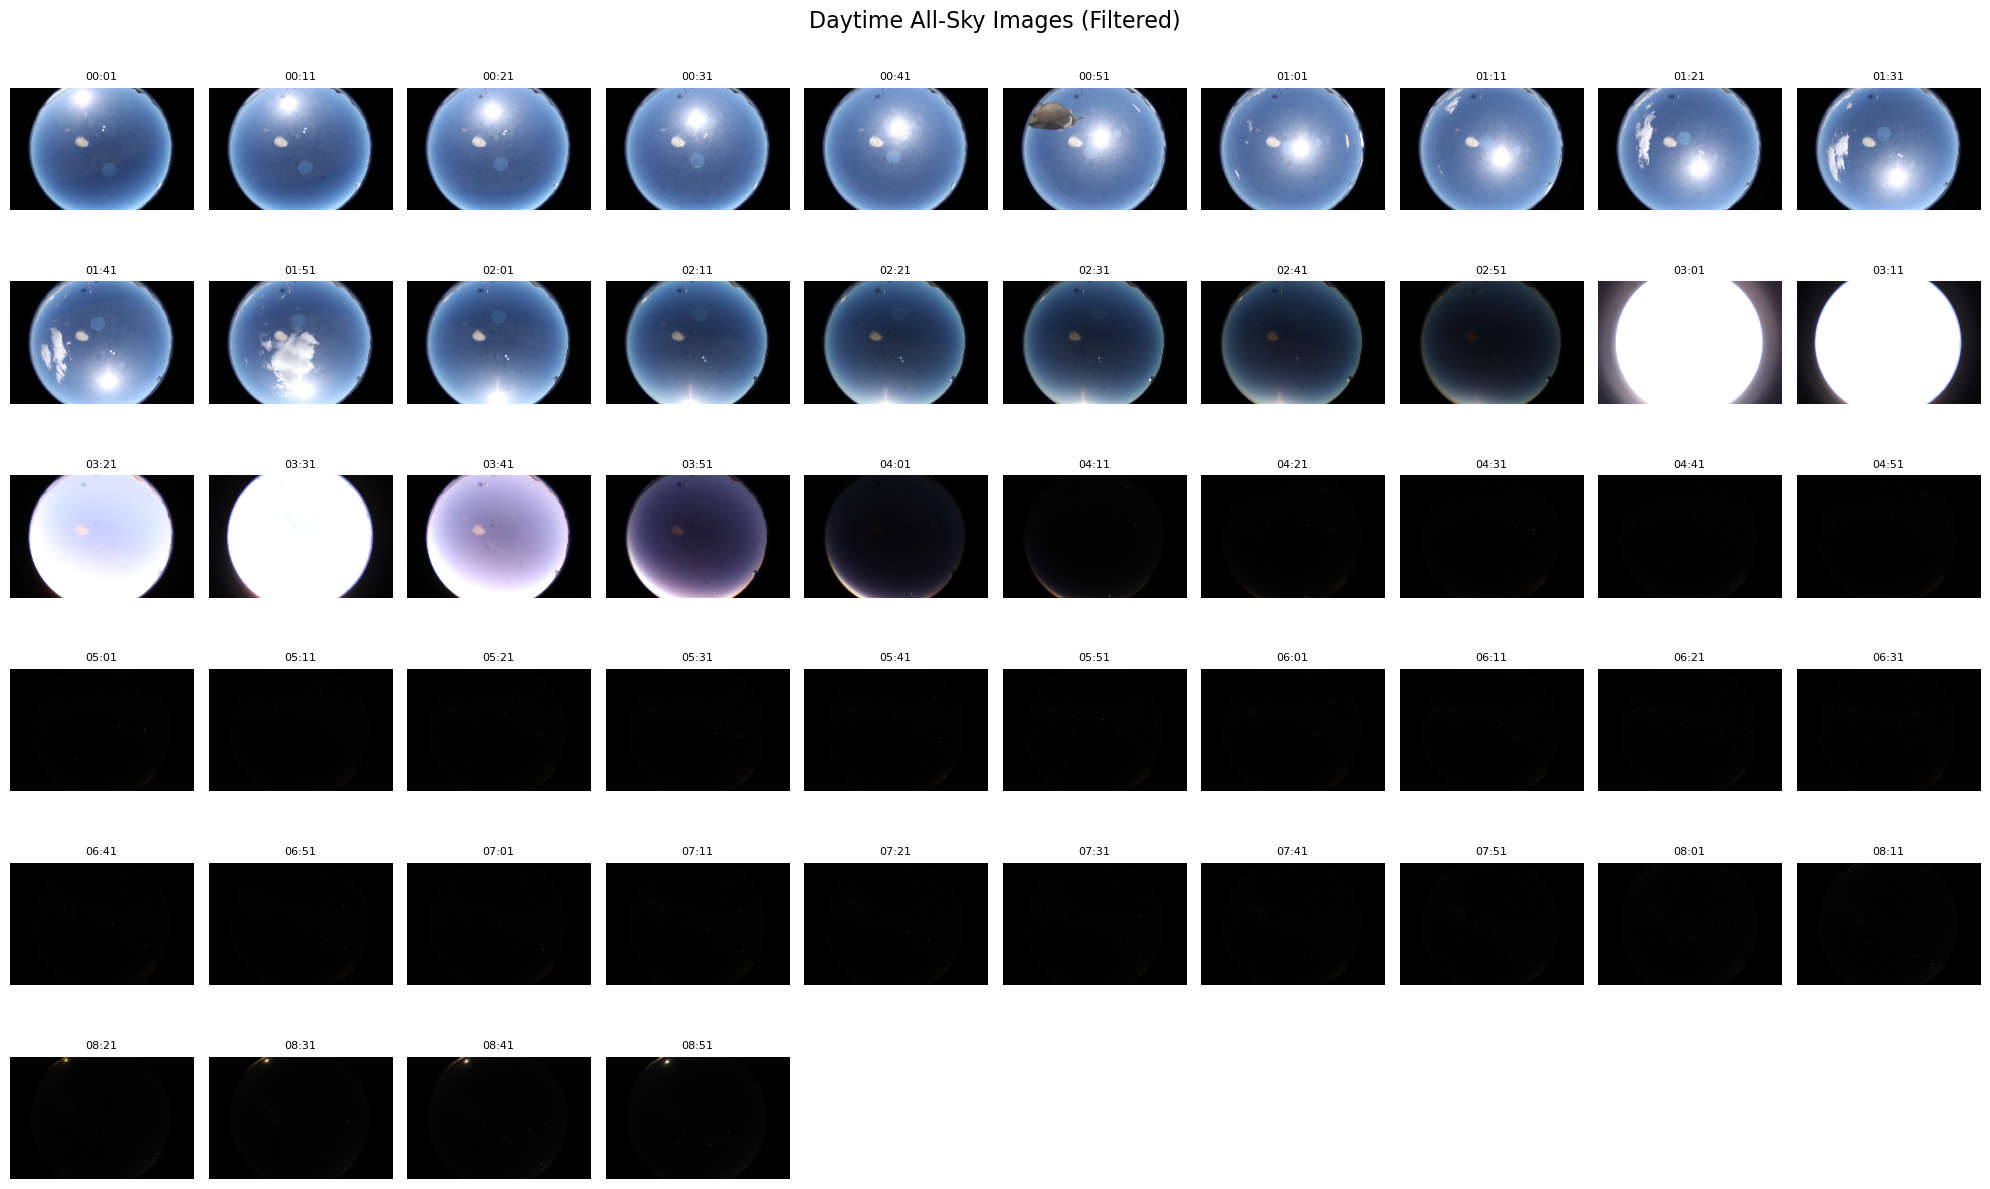

In [6]:
import os
from datetime import datetime, timedelta
from PIL import Image
import matplotlib.pyplot as plt

# Directory of the images
image_directory = "/sdf/data/rubin/offline/s3-backup/lfa/AllSkyCamera/2025/01/22"

# List and sort all .jpg files
image_files = sorted([f for f in os.listdir(image_directory) if f.lower().endswith(".jpg")])

# Parse timestamps
parsed_files = []
for fname in image_files:
    try:
        # Example: asc2501220001.jpg
        base = os.path.splitext(fname)[0]
        if len(base) >= 13 and base.startswith("asc"):
            date_part = base[3:9]  # YYMMDD
            time_part = base[9:]   # HHMM-ish, padded to 4 digits
            dt = datetime.strptime(date_part, "%y%m%d") + timedelta(minutes=int(time_part))
            parsed_files.append((fname, dt))
        else:
            print(f"Skipping unrecognized format: {fname}")
    except Exception as e:
        print(f"Failed to parse timestamp from '{fname}': {e}")

# Filter for daytime images (between ~09:00 and 18:00)
daytime_files = [(f, dt) for f, dt in parsed_files if 0 <= dt.hour <= 8]

if not daytime_files:
    print("❗ No daylight images found in the specified folder.")
else:
    print(f"✅ Found {len(daytime_files)} daylight images.")

    # Select 500 evenly spaced frames (or fewer if not enough)
    step = max(1, len(daytime_files) // 50)
    selected_files = daytime_files[::step]

    # Plot
    n_cols = 10
    n_rows = (len(selected_files) + n_cols - 1) // n_cols
    plt.figure(figsize=(20, 2 * n_rows))

    for i, (fname, dt) in enumerate(selected_files):
        try:
            img_path = os.path.join(image_directory, fname)
            img = Image.open(img_path)
            plt.subplot(n_rows, n_cols, i + 1)
            plt.imshow(img)
            plt.axis('off')
            plt.title(dt.strftime("%H:%M"), fontsize=8)
        except Exception as e:
            print(f"Failed to load image {fname}: {e}")

    plt.tight_layout()
    plt.suptitle("Daytime All-Sky Images (Filtered)", fontsize=16, y=1.02)
    plt.show()


In [46]:
import cv2
import os
import re
from matplotlib import pyplot as plt
#from moviepy.editor import ImageSequenceClip
from IPython.display import HTML

# Function to sort files based on the sequence number
def sort_key(filename):
    match = re.match(r'asc(\d{6})(\d{4}).jpg', filename)
    if match:
        return (match.group(1), int(match.group(2)))
    return filename

# Function to create video from images
def create_video(image_dir, output_file="allsky_video.mp4", fps=10, max_images=200):
    # List all .jpg files in the directory
    images = [img for img in os.listdir(image_dir) if img.endswith(".jpg")]
    images.sort(key=sort_key)

    # Limit to the first max_images
    images = images[:max_images]

    # Read and collect all images
    frames = []
    for image in images:
        img_path = os.path.join(image_dir, image)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert from BGR to RGB
        frames.append(img)

    # Create the video
    #clip = ImageSequenceClip(frames, fps=fps)
    #clip.write_videofile(output_file, codec="libx264")
    
    return output_file

# Function to display video in Jupyter notebook
def display_video(video_file):
    return HTML(f"""
    <video width="640" height="480" controls>
        <source src="{video_file}" type="video/mp4">
        Your browser does not support the video tag.
    </video>
    """)

# Set the directory path containing the images
image_directory = "/sdf/data/rubin/offline/s3-backup/lfa/AllSkyCamera/2025/01/22"
 
# Create the video using the first 200 images
# output_video = create_video(image_directory, fps=10, max_images=70)
# Display the video
# display_video(output_video)


In [39]:
import numpy as np
import rawpy
import cv2
import matplotlib.pyplot as plt
from ipywidgets import Output
from IPython.display import display, clear_output

output = Output()

# Function to read a CR2 file and convert it to a NumPy array
def read_cr2_to_numpy(filepath):
    with rawpy.imread(filepath) as raw:
        rgb = raw.postprocess()
    return np.array(rgb)

# Function to perform Hough transform on an image using OpenCV
def perform_hough_transform(image):
    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    # Detect edges using Canny edge detector
    edges = cv2.Canny(gray, 10, 200, apertureSize=3)
  
    # Perform Hough Line Transform
    lines = cv2.HoughLines(edges, 10, np.pi / 180, 20)
    
    with output:
        if lines is not None:
            print(f"Detected {len(lines)} lines")
        else:
            print("No lines detected")
    
    return lines, edges

# Function to plot the results
def plot_hough_transform(image, edges, lines):
    fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharex=True, sharey=True)
    ax = axes.ravel()
    
    ax[0].imshow(cv2.cvtColor(image, cv2.COLOR_RGB2BGR))
    ax[0].set_title('Input image')
    
    ax[1].imshow(edges, cmap='gray')
    ax[1].set_title('Canny edges')
    
    if lines is not None:
        img_with_lines = image.copy()
        for rho, theta in lines[:, 0]:
            a = np.cos(theta)
            b = np.sin(theta)
            x0 = a * rho
            y0 = b * rho
            x1 = int(x0 + 1000 * (-b))
            y1 = int(y0 + 1000 * (a))
            x2 = int(x0 - 1000 * (-b))
            y2 = int(y0 - 1000 * (a))
            cv2.line(img_with_lines, (x1, y1), (x2, y2), (255, 0, 0), 2)
        ax[2].imshow(cv2.cvtColor(img_with_lines, cv2.COLOR_RGB2BGR))
    else:
        ax[2].imshow(cv2.cvtColor(image, cv2.COLOR_RGB2BGR))
    ax[2].set_title('Hough transform')
    
    for a in ax:
        a.set_axis_off()
        a.set_adjustable('box')
    
    plt.tight_layout()
    plt.show()

# Use the previously selected CR2 file path
directory = directory_input.value
filename = file_dropdown.value
filepath = os.path.join(directory, filename)

with output:
    print(f"Using file: {filepath}")

# Read the image
image = read_cr2_to_numpy(filepath)

# Perform Hough transform
lines, edges = perform_hough_transform(image)

# Plot the results
with output:
    plot_hough_transform(image, edges, lines)

# Display the output widget
display(output)


TypeError: join() argument must be str, bytes, or os.PathLike object, not 'NoneType'

In [40]:
# this cell produces a listing in time order of images taken

import os
import exifread
from ipywidgets import widgets
from IPython.display import display, clear_output

# Function to list all CR2 files in a directory
def list_cr2_files(directory):
    return [f for f in os.listdir(directory) if f.lower().endswith('.cr2')]

# Function to extract capture time from CR2 file
def get_capture_time(filepath):
    with open(filepath, 'rb') as f:
        tags = exifread.process_file(f, stop_tag='EXIF DateTimeOriginal')
        date_taken = tags.get('EXIF DateTimeOriginal')
        return str(date_taken) if date_taken else 'N/A'

# Function to get capture times for all CR2 files in a directory
def get_capture_times(directory):
    files = list_cr2_files(directory)
    capture_times = []
    for file in files:
        filepath = os.path.join(directory, file)
        capture_time = get_capture_time(filepath)
        capture_times.append((file, capture_time))
    return capture_times

# Directory input widget
directory_input = widgets.Text(
    value='',
    placeholder='Enter directory path',
    description='Directory:',
    disabled=False
)

# Button to display capture times
display_button = widgets.Button(
    description='Show Capture Times',
    disabled=False,
    button_style='', 
    tooltip='Click to display capture times',
    icon='clock'
)

output = widgets.Output()

# Function to display capture times when button is clicked
def on_display_button_clicked(b):
    clear_output(wait=True)
    display(directory_input, display_button, output)
    directory = directory_input.value
    if os.path.isdir(directory):
        capture_times = get_capture_times(directory)
        # Sort capture times in ascending order
        capture_times.sort(key=lambda x: x[1])
        with output:
            print(f"{'Filename':<40} {'Capture Time':<20}")
            print('-' * 60)
            for filename, capture_time in capture_times:
                print(f"{filename:<40} {capture_time:<20}")
    else:
        with output:
            print("Invalid directory")

display_button.on_click(on_display_button_clicked)

# Display the widgets
display(directory_input, display_button, output)


ModuleNotFoundError: No module named 'exifread'

In [41]:
# this cell uses pixel color to flag cloud pixels, as non-blue-sky. 
# slider allows for adjustment of Gaussian kernel, blueness threshold

import rawpy
import numpy as np
import cv2
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, FloatSlider
from IPython.display import display

# Function to read a CR2 file and convert it to a NumPy array
def read_cr2_to_numpy(filepath):
    with rawpy.imread(filepath) as raw:
        rgb = raw.postprocess()
    return np.array(rgb)

# Function to segment clouds in the image
def segment_clouds(image, threshold, kernel_size, central_hue):
    # Ensure kernel_size is an odd integer
    kernel_size = (kernel_size, kernel_size) if kernel_size % 2 == 1 else (kernel_size+1, kernel_size+1)
    
    # Apply Gaussian Blur to the image
    blurred_image = cv2.GaussianBlur(image, kernel_size, 0)
    
    # Convert image to HSV color space
    hsv = cv2.cvtColor(blurred_image, cv2.COLOR_RGB2HSV)
    
    # Define color range for blue sky in HSV
    lower_blue = np.array([central_hue - threshold, 50, 50])
    upper_blue = np.array([central_hue + threshold, 255, 255])
    
    # Create a mask to segment blue sky
    mask = cv2.inRange(hsv, lower_blue, upper_blue)
    
    # Invert mask to segment clouds
    cloud_mask = cv2.bitwise_not(mask)
    
    # Apply mask to the original image
    segmented_image = cv2.bitwise_and(image, image, mask=cloud_mask)
    
    return segmented_image, cloud_mask

# Function to display the original and segmented images
def display_images(filepath, threshold, kernel_size, central_hue):
    global segmented_image, cloud_mask  # Save the segmented image and cloud mask globally
    # Read the image
    image = read_cr2_to_numpy(filepath)
    
    # Segment the clouds
    segmented_image, cloud_mask = segment_clouds(image, threshold, kernel_size, central_hue)
    
    # Display the images
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    axes[0].imshow(image)
    axes[0].set_title('Original Image')
    axes[0].axis('off')
    
    axes[1].imshow(cloud_mask, cmap='gray')
    axes[1].set_title('Cloud Mask')
    axes[1].axis('off')
    
    axes[2].imshow(segmented_image)
    axes[2].set_title('Segmented Image')
    axes[2].axis('off')

    print('Threshold:', threshold)
    print('Kernel Size:', kernel_size)
    print('Central Hue:', central_hue)
    
    plt.show()

# Path to your CR2 file
filepath = '/sdf/data/rubin/offline/s3-backup/lfa/AllSkyCamera/2024/07/25/asc2407250050.cr2' 

# Interactive widgets for threshold, kernel size, and central hue adjustment
interact(display_images, 
         filepath=filepath, 
         threshold=FloatSlider(value=70, min=0, max=250, step=10, description='Threshold'),
         kernel_size=IntSlider(value=15, min=1, max=100, step=2, description='Kernel Size'),
         central_hue=FloatSlider(value=60, min=0, max=250, step=1, description='Central Hue'))


interactive(children=(Text(value='/sdf/data/rubin/offline/s3-backup/lfa/AllSkyCamera/2024/07/25/asc2407250050.…

<function __main__.display_images(filepath, threshold, kernel_size, central_hue)>

In [42]:
# Ensure matplotlib plots are displayed inline in the notebook
%matplotlib inline

import os
import time
from PIL import Image
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
from ipywidgets import Output

output = Output()

# Function to list files in the directory
def list_files(directory, extension=".jpg"):
    files = sorted([f for f in os.listdir(directory) if f.lower().endswith(extension)])
    with output:
        print(f"Files in directory '{directory}': {files}")
    return files

# Function to filter files based on sequence numbers
def filter_files(files, start_seq, stop_seq):
    filtered_files = []
    for file in files:
        try:
            seq_num = int(file[6:10])
            if start_seq <= seq_num <= stop_seq:
                filtered_files.append(file)
        except ValueError:
            pass
    with output:
        print(f"Filtered files: {filtered_files}")
    return filtered_files

# Function to open and process a JPG file
def open_file(filepath):
    try:
        image = Image.open(filepath)
        return image
    except Exception as e:
        with output:
            print(f"Error opening file '{filepath}': {e}")
        return None

# Function to display the image in the notebook using matplotlib
def display_image(image):
    if image:
        plt.figure(figsize=(10, 10))
        plt.imshow(image)
        plt.axis('off')  # Hide axes
        plt.show()

# Directory input widget
directory_input = widgets.Text(
    value='/sdf/data/rubin/offline/s3-backup/lfa/AllSkyCamera/2024/07/26',  # Default directory path
    placeholder='Enter directory path',
    description='Directory:',
    disabled=False
)

# Slider for setting the delay
delay_slider = widgets.FloatSlider(
    value=1.0,
    min=0.1,
    max=10.0,
    step=0.1,
    description='Delay (s):',
    disabled=False
)

# Widgets for setting start and stop sequence numbers
start_seq_input = widgets.IntText(
    value=1,
    description='Start Seq:',
    disabled=False
)

stop_seq_input = widgets.IntText(
    value=100,
    description='Stop Seq:',
    disabled=False
)

# Playback control buttons
play_button = widgets.Button(description="Play", icon="play")
pause_button = widgets.Button(description="Pause", icon="pause")
forward_button = widgets.Button(description="Forward", icon="forward")
backward_button = widgets.Button(description="Backward", icon="backward")

# Function to update the file list based on the directory
def update_files(change):
    clear_output(wait=True)
    display_controls()
    directory = directory_input.value
    if os.path.isdir(directory):
        global files
        files = list_files(directory)
        global file_index
        file_index = 0
    else:
        with output:
            print(f"Directory '{directory}' does not exist or is not a directory.")
    display(output)  # Ensure output is displayed

directory_input.observe(update_files, names='value')

# Function to display the image at the current index
def display_current_image():
    global file_index
    if 0 <= file_index < len(files):
        filepath = os.path.join(directory_input.value, files[file_index])
        with output:
            print(f"Displaying file '{filepath}'")
        image = open_file(filepath)
        display_image(image)
        display(output)  # Ensure output is displayed
    else:
        with output:
            print(f"Index out of range: {file_index}")
        display(output)  # Ensure output is displayed

# Play slideshow function
def play_slideshow():
    global playing
    playing = True
    start_seq = start_seq_input.value
    stop_seq = stop_seq_input.value
    directory = directory_input.value
    all_files = list_files(directory)
    global files
    files = filter_files(all_files, start_seq, stop_seq)
    if not files:
        with output:
            print("No files to display within the specified sequence range.")
        display(output)  # Ensure output is displayed
        return
    while playing and file_index < len(files):
        display_current_image()
        time.sleep(delay_slider.value)
        clear_output(wait=True)
        display_controls()
        next_image()

# Pause slideshow function
def pause_slideshow(b):
    global playing
    playing = False

# Next image function
def next_image():
    global file_index
    if file_index < len(files) - 1:
        file_index += 1

# Previous image function
def previous_image():
    global file_index
    if file_index > 0:
        file_index -= 1

# Play button click event
def on_play_button_clicked(b):
    global playing
    if not playing:
        playing = True
        play_slideshow()

# Forward button click event
def on_forward_button_clicked(b):
    global playing
    playing = False
    next_image()
    display_current_image()

# Backward button click event
def on_backward_button_clicked(b):
    global playing
    playing = False
    previous_image()
    display_current_image()

# Connect button click events to functions
play_button.on_click(on_play_button_clicked)
pause_button.on_click(pause_slideshow)
forward_button.on_click(on_forward_button_clicked)
backward_button.on_click(on_backward_button_clicked)

# Function to display all controls
def display_controls():
    display(directory_input, start_seq_input, stop_seq_input, delay_slider, play_button, pause_button, forward_button, backward_button, output)

# Display the widgets
display_controls()


Text(value='/sdf/data/rubin/offline/s3-backup/lfa/AllSkyCamera/2024/07/26', description='Directory:', placehol…

IntText(value=1, description='Start Seq:')

IntText(value=100, description='Stop Seq:')

FloatSlider(value=1.0, description='Delay (s):', max=10.0, min=0.1)

Button(description='Play', icon='play', style=ButtonStyle())

Button(description='Pause', icon='pause', style=ButtonStyle())

Button(description='Forward', icon='forward', style=ButtonStyle())

Button(description='Backward', icon='backward', style=ButtonStyle())

Output()

In [ ]:
import os
import re
import ipywidgets as widgets
from IPython.display import display, Image

# Function to sort files based on the sequence number
def sort_key(filename):
    match = re.match(r'asc(\d{6})(\d{4}).jpg', filename)
    if match:
        return (match.group(1), int(match.group(2)))
    return filename

# Function to display images one by one
def display_images_one_by_one(image_dir, max_images=100):
    # List all .jpg files in the directory
    images = [img for img in os.listdir(image_dir) if img.endswith(".jpg")]
    images.sort(key=sort_key)

    # Limit to the first max_images
    images = images[:max_images]

    # Set up widgets for stepping through images
    img_widget = widgets.Image(format='jpg')
    display(img_widget)

    def show_image(index):
        img_path = os.path.join(image_dir, images[index])
        with open(img_path, 'rb') as file:
            img_widget.value = file.read()

    # Create and display the slider for navigation
    index_slider = widgets.IntSlider(min=0, max=len(images)-1, step=1, description="Frame")
    widgets.interactive(show_image, index=index_slider)
    display(index_slider)

# Set the directory path containing the images
image_directory = "/sdf/data/rubin/offline/s3-backup/lfa/AllSkyCamera/2024/07/26"

# Display images one by one
display_images_one_by_one(image_directory, max_images=100)


In [ ]:
import os
import numpy as np
from PIL import Image
import ipywidgets as widgets
from IPython.display import display

def bin_image(image, bin_size):
    """Bin the image by the given bin_size (e.g., 3x3)."""
    (w, h) = image.size
    w_new, h_new = w // bin_size, h // bin_size
    image_array = np.array(image)
    
    # Reshape and average
    binned_image = image_array.reshape(h_new, bin_size, w_new, bin_size, -1).mean(axis=(1, 3))
    return Image.fromarray(binned_image.astype('uint8'))

def load_images_from_directory(directory, max_images=None):
    images = []
    filenames = sorted([f for f in os.listdir(directory) if f.endswith('.jpg')])
    
    if max_images:
        filenames = filenames[:max_images]
    
    for filename in filenames:
        image = Image.open(os.path.join(directory, filename))
        image = bin_image(image, 3)  # Bin the image 3x3
        images.append(image)
    
    return images, filenames

def display_images(images, filenames):
    current_frame = 0
    image_widget = widgets.Image(value=images[current_frame].tobytes())
    image_widget.layout.height = '600px'  # Adjust the display height if needed
    image_widget.layout.width = '600px'

    def update_image(change):
        nonlocal current_frame
        current_frame = current_frame + change
        current_frame = max(0, min(len(images) - 1, current_frame))
        image_widget.value = images[current_frame].tobytes()
        label.value = filenames[current_frame]

    next_button = widgets.Button(description="Next Frame")
    prev_button = widgets.Button(description="Previous Frame")
    
    next_button.on_click(lambda b: update_image(1))
    prev_button.on_click(lambda b: update_image(-1))
    
    label = widgets.Label(filenames[current_frame])

    display(widgets.HBox([prev_button, next_button]))
    display(image_widget)
    display(label)

# Example usage
directory = "/sdf/data/rubin/offline/s3-backup/lfa/AllSkyCamera/2024/07/26"
images, filenames = load_images_from_directory(directory, max_images=200)
display_images(images, filenames)


In [ ]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import ipywidgets as widgets
from IPython.display import display, clear_output
from PIL import Image
from PIL.ExifTags import TAGS

# Function to load images from the directory
def load_images_from_directory(directory, max_images=100):
    image_files = sorted([f for f in os.listdir(directory) if f.endswith('.jpg')])[:max_images]
    images = []
    for file in image_files:
        try:
            img = Image.open(os.path.join(directory, file))
            images.append(img)
        except Exception as e:
            print(f"Error loading image {file}: {e}")
    return images, image_files

# Function to extract the timestamp from an image's EXIF data
def get_image_timestamp(image_path):
    try:
        img = Image.open(image_path)
        exif_data = img._getexif()
        if exif_data:
            for tag, value in exif_data.items():
                if TAGS.get(tag) == 'DateTimeOriginal':
                    timestamp = value
                    return timestamp
        return None
    except Exception as e:
        print(f"Error extracting timestamp: {e}")
        return None

# Function to save contrail data to a file
def save_contrail_data(filename, frame_number, timestamp):
    with open(filename, 'a') as file:
        file.write(f"Frame {frame_number}, Timestamp: {timestamp}\n")

# Function to display the images with navigation and contrail recording options
def display_images(images, filenames, directory):
    current_frame = 0

    # Initial setup for image display
    image_widget = widgets.Output()

    def show_image(frame_index):
        with image_widget:
            clear_output(wait=True)
            plt.imshow(images[frame_index])
            plt.axis('off')
            plt.show()

    def update_image(step):
        nonlocal current_frame
        current_frame = (current_frame + step) % len(images)
        label.value = filenames[current_frame]
        show_image(current_frame)
        status.value = ""

    def save_contrail_action(_):
        nonlocal current_frame
        image_path = os.path.join(directory, filenames[current_frame])
        timestamp = get_image_timestamp(image_path)
        if timestamp:
            save_contrail_data('contrails.dat', current_frame, timestamp)
            status.value = f"Saved contrail data for frame {current_frame + 1}"
        else:
            status.value = f"No timestamp found for frame {current_frame + 1}"

    # Setup the buttons
    next_button = widgets.Button(description="Next Frame")
    prev_button = widgets.Button(description="Previous Frame")
    contrail_button = widgets.Button(description="Contrails")

    # Labels and status display
    label = widgets.Label(value=filenames[current_frame])
    status = widgets.Label(value="")

    # Define button actions
    next_button.on_click(lambda _: update_image(1))
    prev_button.on_click(lambda _: update_image(-1))
    contrail_button.on_click(save_contrail_action)

    # Arrange the widgets
    buttons = widgets.HBox([prev_button, next_button, contrail_button])
    display(widgets.VBox([image_widget, label, buttons, status]))

    # Display the first image
    show_image(current_frame)

# Example usage
directory = '/sdf/data/rubin/offline/s3-backup/lfa/AllSkyCamera/2024/06/12/'
images, filenames = load_images_from_directory(directory, max_images=150)  # Adjust max_images if needed
display_images(images, filenames, directory)


In [ ]:
import os
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
from PIL import Image
from PIL.ExifTags import TAGS

# Function to load images from the directory
def load_images_from_directory(directory, max_images=100):
    image_files = sorted([f for f in os.listdir(directory) if f.endswith('.jpg')])[:max_images]
    images = []
    for file in image_files:
        try:
            img = Image.open(os.path.join(directory, file))
            images.append(img)
        except Exception as e:
            print(f"Error loading image {file}: {e}")
    return images, image_files

# Function to extract the timestamp from an image's EXIF data
def get_image_timestamp(image_path):
    try:
        img = Image.open(image_path)
        exif_data = img._getexif()
        if exif_data:
            for tag, value in exif_data.items():
                if TAGS.get(tag) == 'DateTimeOriginal':
                    return value
        return None
    except Exception as e:
        print(f"Error extracting timestamp: {e}")
        return None

# Function to save contrail data to a file
def save_contrail_data(filename, image_name, timestamp):
    with open(filename, 'a') as file:
        file.write(f"Image: {image_name}, Timestamp: {timestamp}\n")

# Function to display the images with navigation and contrail recording options
def display_images(images, filenames, directory):
    current_frame = 0

    # Initial setup for image display
    image_widget = widgets.Output()

    def show_image(frame_index):
        with image_widget:
            clear_output(wait=True)
            plt.imshow(images[frame_index])
            plt.axis('off')
            plt.show()

    def update_image(step):
        nonlocal current_frame
        current_frame = (current_frame + step) % len(images)
        label.value = filenames[current_frame]
        show_image(current_frame)
        status.value = ""

    def save_clear_contrail_action(_):
        nonlocal current_frame
        image_path = os.path.join(directory, filenames[current_frame])
        timestamp = get_image_timestamp(image_path)
        if timestamp:
            save_contrail_data('ClearSkyContrails.dat', filenames[current_frame], timestamp)
            status.value = f"Saved clear sky contrail data for frame {current_frame + 1}"
        else:
            status.value = f"No timestamp found for frame {current_frame + 1}"

    def save_cloudy_contrail_action(_):
        nonlocal current_frame
        image_path = os.path.join(directory, filenames[current_frame])
        timestamp = get_image_timestamp(image_path)
        if timestamp:
            save_contrail_data('CloudySkyContrails.dat', filenames[current_frame], timestamp)
            status.value = f"Saved cloudy sky contrail data for frame {current_frame + 1}"
        else:
            status.value = f"No timestamp found for frame {current_frame + 1}"

    # Setup the buttons
    next_button = widgets.Button(description="Next Frame")
    prev_button = widgets.Button(description="Previous Frame")
    clear_contrail_button = widgets.Button(description="Clear Sky Contrails")
    cloudy_contrail_button = widgets.Button(description="Cloudy Sky Contrails")

    # Labels and status display
    label = widgets.Label(value=filenames[current_frame])
    status = widgets.Label(value="")

    # Define button actions
    next_button.on_click(lambda _: update_image(1))
    prev_button.on_click(lambda _: update_image(-1))
    clear_contrail_button.on_click(save_clear_contrail_action)
    cloudy_contrail_button.on_click(save_cloudy_contrail_action)

    # Arrange the widgets
    buttons = widgets.HBox([prev_button, next_button, clear_contrail_button, cloudy_contrail_button])
    display(widgets.VBox([image_widget, label, buttons, status]))

    # Display the first image
    show_image(current_frame)

# Example usage
directory = '/sdf/data/rubin/offline/s3-backup/lfa/AllSkyCamera/2024/09/03'
images, filenames = load_images_from_directory(directory, max_images=150)
display_images(images, filenames, directory)


In [ ]:
import requests
import folium
from datetime import datetime

# Step 1: Define the Cerro Pachón Observatory location
cerro_pachon_coords = (-30.2407, -70.7366)  # Latitude, Longitude

# Step 2: Define your FlightAware API credentials
api_key = "1Q0ffUe5VyAsIASAFAwcJiYjs7Mse0nh"  # Replace with your FlightAware API key

# Step 3: Set the date and time for the query (UTC)
query_time = datetime.utcnow().strftime('%Y-%m-%d %H:%M:%S')

# Step 4: Make a request to the FlightAware API to get flights in the vicinity
# This is a hypothetical example; the actual FlightAware API call might differ
# You will need to refer to the FlightXML documentation for the exact API call
response = requests.get(
    "https://flightxml.flightaware.com/json/FlightXML2/Search",
    params={
        "query": f"-latlong \"{cerro_pachon_coords[0]},{cerro_pachon_coords[1]}\"",
        "howMany": 15,
        "offset": 0
    },
    auth=(api_key, "ozzie4Flightaware!")  # Replace with your credentials
)

# Step 5: Parse the response
flights = response.json().get('SearchResult', {}).get('aircraft', [])

# Step 6: Create a map centered on Cerro Pachón
m = folium.Map(location=cerro_pachon_coords, zoom_start=10)

# Step 7: Add a marker for Cerro Pachón
folium.Marker(
    cerro_pachon_coords,
    popup="Cerro Pachón Observatory",
    icon=folium.Icon(color="red")
).add_to(m)

# Step 8: Add markers for each flight
for flight in flights:
    lat = flight.get('latitude')
    lon = flight.get('longitude')
    altitude = flight.get('altitude')
    flight_id = flight.get('ident')
    folium.Marker(
        location=[lat, lon],
        popup=f"Flight: {flight_id}, Altitude: {altitude} ft",
        icon=folium.Icon(color="blue")
    ).add_to(m)

# Step 9: Display the map
m


In [ ]:
print(response.text)